In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


In [ ]:
# ============================================================
# UPLOAD FILE - Jalankan cell ini di Google Colab
# ============================================================
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'File terupload: {filename}')

Saving balanced_stunting_normal_reduced_ML.csv to balanced_stunting_normal_reduced_ML.csv
File terupload: balanced_stunting_normal_reduced_ML.csv


In [ ]:
# Load dataset
df = pd.read_csv(filename, sep=';')

print('=' * 60)
print('📊 INFORMASI DATASET')
print('=' * 60)
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'\nNama Kolom     : {list(df.columns)}')
print('\n--- 5 Data Pertama ---')
df.head()

📊 INFORMASI DATASET
Jumlah baris   : 30,902
Jumlah kolom   : 6

Nama Kolom     : ['Jenis Kelamin', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'Stunting', 'Wasting']

--- 5 Data Pertama ---


,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,Perempuan,2,52.9,7.7,Stunted,Risk of Overweight
1,Laki-laki,0,43.5,4.7,Severely Stunted,Risk of Overweight
2,Laki-laki,21,79.0,12.5,Stunted,Normal weight
3,Laki-laki,21,94.3,14.1,Tall,Risk of Overweight
4,Laki-laki,13,84.8,6.8,Tall,Severely Underweight


In [ ]:
# Tipe data
print('--- Tipe Data ---')
print(df.dtypes)
print()
df.info()

--- Tipe Data ---
Jenis Kelamin         object
Umur (bulan)           int64
Tinggi Badan (cm)    float64
Berat Badan (kg)     float64
Stunting              object
Wasting               object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30902 entries, 0 to 30901
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Jenis Kelamin      30902 non-null  object 
 1   Umur (bulan)       30902 non-null  int64  
 2   Tinggi Badan (cm)  30902 non-null  float64
 3   Berat Badan (kg)   30902 non-null  float64
 4   Stunting           30902 non-null  object 
 5   Wasting            30902 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 1.4+ MB


In [ ]:
# Statistik deskriptif
print('=' * 60)
print('📈 STATISTIK DESKRIPTIF (Variabel Numerik)')
print('=' * 60)
df.describe(include='all').T

📈 STATISTIK DESKRIPTIF (Variabel Numerik)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Jenis Kelamin,30902,2,Laki-laki,15514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Umur (bulan),30902.0,NaN,NaN,NaN,12.37784,7.299176,0.0,6.0,12.0,19.0,24.0
Tinggi Badan (cm),30902.0,NaN,NaN,NaN,70.808436,11.400802,42.6,63.4,71.7,78.2,97.6
Berat Badan (kg),30902.0,NaN,NaN,NaN,9.371546,3.309207,1.0,7.0,9.3,11.9,17.2
Stunting,30902,4,Stunted,15039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wasting,30902,4,Risk of Overweight,12989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Distribusi label target
print('=' * 60)
print('🎯 DISTRIBUSI LABEL TARGET (Stunting)')
print('=' * 60)
target_counts = df['Stunting'].value_counts()
target_pct = df['Stunting'].value_counts(normalize=True) * 100
target_df = pd.DataFrame({'Jumlah': target_counts, 'Persentase (%)': target_pct.round(2)})
print(target_df)
print(f'\nTotal Data: {len(df):,}')

🎯 DISTRIBUSI LABEL TARGET (Stunting)
                  Jumlah  Persentase (%)
Stunting                                
Stunted            15039           48.67
Severely Stunted    5333           17.26
Tall                5265           17.04
Normal              5265           17.04

Total Data: 30,902


In [ ]:
# ============================================================
# 2.1 Cek Missing Values
# ============================================================
print('=' * 60)
print('🔍 PENGECEKAN MISSING VALUES')
print('=' * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Persentase (%)': missing_pct.round(2)})
print(missing_df)

if missing.sum() == 0:
    print('\n✅ Tidak ada missing values!')
else:
    print(f'\n⚠️ Total missing values: {missing.sum()}')
    df.dropna(inplace=True)
    print(f'✅ Missing values berhasil dihapus. Data sekarang: {df.shape[0]:,} baris')

🔍 PENGECEKAN MISSING VALUES
                   Missing Values  Persentase (%)
Jenis Kelamin                   0             0.0
Umur (bulan)                    0             0.0
Tinggi Badan (cm)               0             0.0
Berat Badan (kg)                0             0.0
Stunting                        0             0.0
Wasting                         0             0.0

✅ Tidak ada missing values!


📊 DETEKSI OUTLIER (Metode IQR)
Umur (bulan): Q1=6.0, Q3=19.0, IQR=13.00, Lower=-13.50, Upper=38.50, Outlier=0
Tinggi Badan (cm): Q1=63.4, Q3=78.2, IQR=14.80, Lower=41.20, Upper=100.40, Outlier=0
Berat Badan (kg): Q1=7.0, Q3=11.9, IQR=4.90, Lower=-0.35, Upper=19.25, Outlier=0


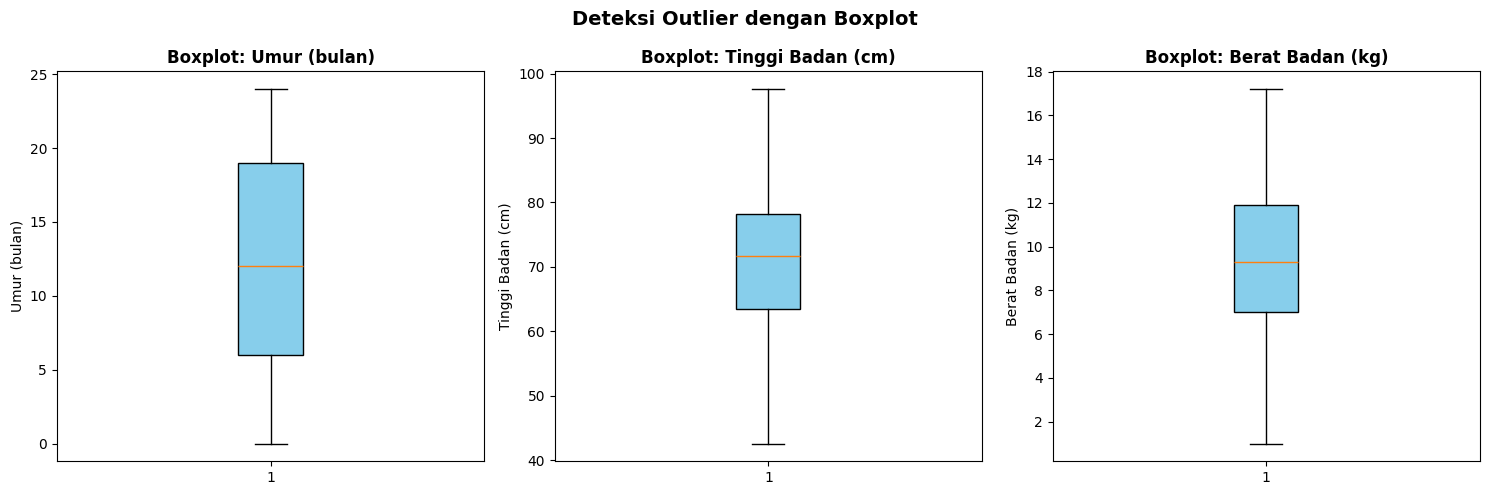


💡 Catatan: Outlier dipertahankan karena dapat merepresentasikan kasus klinis yang valid (misal bayi prematur).


In [ ]:
# ============================================================
# 2.3 Deteksi & Penanganan Outlier (IQR)
# ============================================================
print('=' * 60)
print('📊 DETEKSI OUTLIER (Metode IQR)')
print('=' * 60)

num_cols = ['Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']
outlier_info = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower': lower, 'Upper': upper, 'Outlier': n_outlier}
    print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR:.2f}, Lower={lower:.2f}, Upper={upper:.2f}, Outlier={n_outlier}')

# Visualisasi boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='skyblue'))
    axes[i].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)
plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

# Keterangan: Outlier di data klinis (khususnya pediatri) sering merupakan data valid
# (misal bayi prematur dengan berat sangat rendah). Outlier TIDAK dihapus.
print('\n💡 Catatan: Outlier dipertahankan karena dapat merepresentasikan kasus klinis yang valid (misal bayi prematur).')

In [ ]:
# ============================================================
# 2.4 Encoding Variabel Kategorikal
# ============================================================
print('=' * 60)
print('🔠 ENCODING VARIABEL KATEGORIKAL')
print('=' * 60)

df_encoded = df.copy()
le_dict = {}

cat_cols = ['Jenis Kelamin', 'Wasting', 'Stunting']
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {mapping}')

print('\n✅ Encoding selesai!')
print('\n--- Preview data setelah encoding ---')
df_encoded.head()

🔠 ENCODING VARIABEL KATEGORIKAL
Jenis Kelamin: {'Laki-laki': np.int64(0), 'Perempuan': np.int64(1)}
Wasting: {'Normal weight': np.int64(0), 'Risk of Overweight': np.int64(1), 'Severely Underweight': np.int64(2), 'Underweight': np.int64(3)}
Stunting: {'Normal': np.int64(0), 'Severely Stunted': np.int64(1), 'Stunted': np.int64(2), 'Tall': np.int64(3)}

✅ Encoding selesai!

--- Preview data setelah encoding ---


,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,1,2,52.9,7.7,2,1
1,0,0,43.5,4.7,1,1
2,0,21,79.0,12.5,2,0
3,0,21,94.3,14.1,3,1
4,0,13,84.8,6.8,3,2


In [ ]:
# ============================================================
# 2.5 Pisahkan Fitur (X) dan Target (y)
# ============================================================
X = df_encoded.drop(columns=['Stunting'])
y = df_encoded['Stunting']

print(f'Dimensi X (Fitur) : {X.shape}')
print(f'Dimensi y (Target): {y.shape}')
print(f'\nFitur yang digunakan: {list(X.columns)}')
print(f'\nDistribusi kelas target (encoded):')
print(y.value_counts())

Dimensi X (Fitur) : (30902, 5)
Dimensi y (Target): (30902,)

Fitur yang digunakan: ['Jenis Kelamin', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'Wasting']

Distribusi kelas target (encoded):
Stunting
2    15039
1     5333
3     5265
0     5265
Name: count, dtype: int64


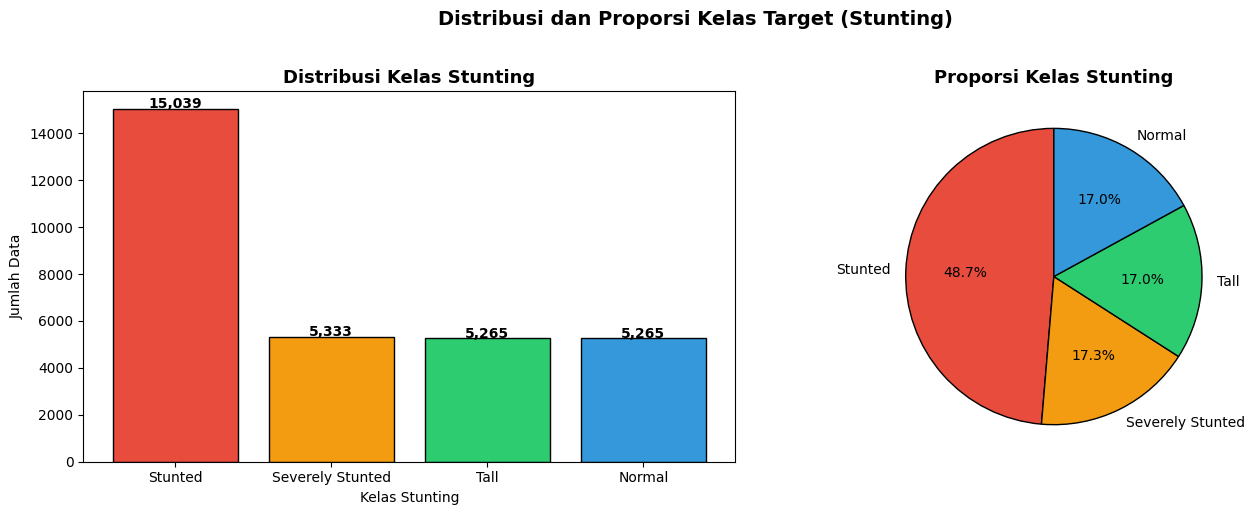

In [ ]:
# ============================================================
# 3.1 Distribusi Kelas Target
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_bar = ['#e74c3c','#f39c12','#2ecc71','#3498db']
target_counts = df['Stunting'].value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=colors_bar, edgecolor='black')
axes[0].set_title('Distribusi Kelas Stunting', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kelas Stunting')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=90, wedgeprops={'edgecolor':'black'})
axes[1].set_title('Proporsi Kelas Stunting', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi dan Proporsi Kelas Target (Stunting)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()

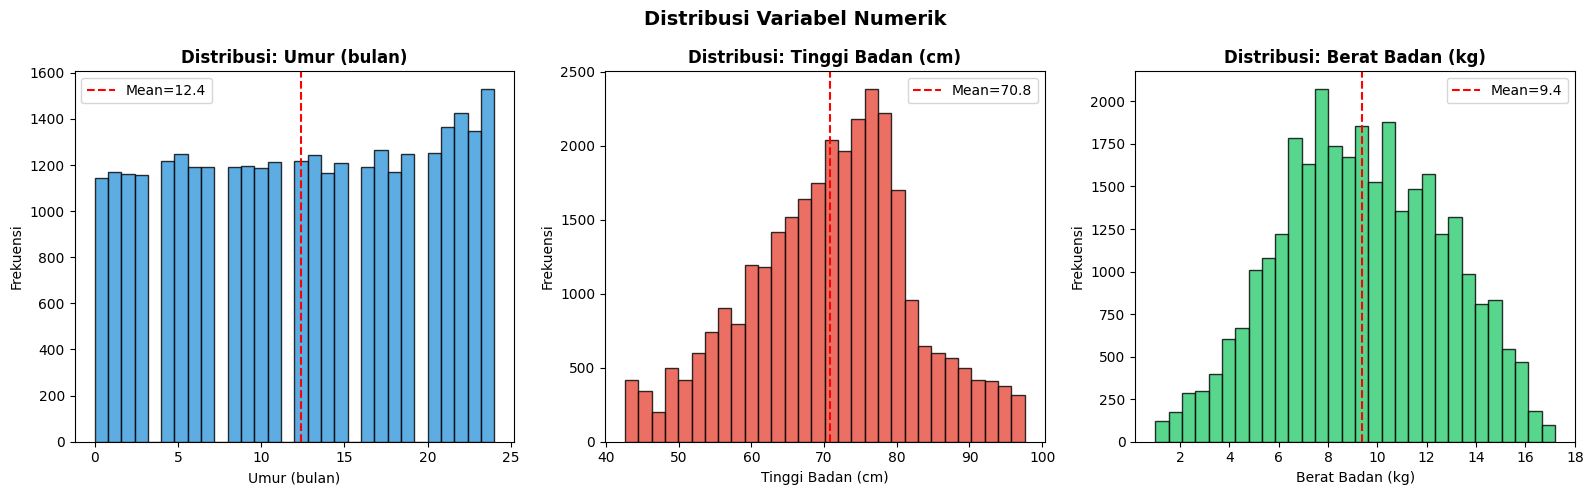

In [ ]:
# ============================================================
# 3.2 Distribusi Fitur Numerik
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
num_cols = ['Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']
palette_hist = ['#3498db', '#e74c3c', '#2ecc71']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color=palette_hist[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].legend()

plt.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_numerik.png', dpi=150, bbox_inches='tight')
plt.show()

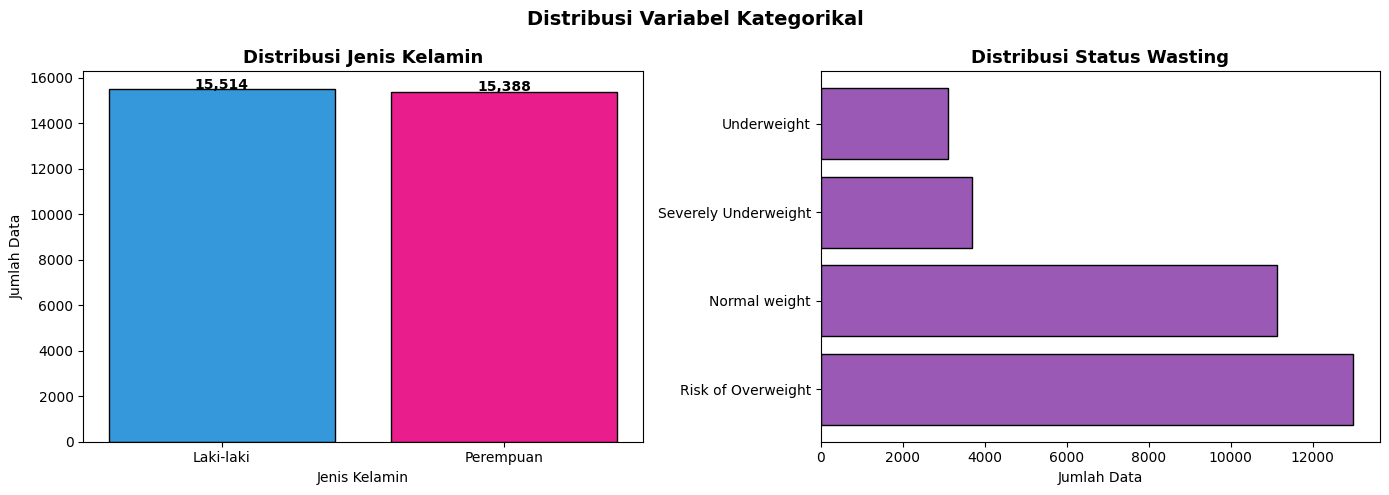

In [ ]:
# ============================================================
# 3.3 Distribusi Jenis Kelamin
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi jenis kelamin
jk_counts = df['Jenis Kelamin'].value_counts()
axes[0].bar(jk_counts.index, jk_counts.values, color=['#3498db','#e91e8c'], edgecolor='black')
axes[0].set_title('Distribusi Jenis Kelamin', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jenis Kelamin')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(jk_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

# Distribusi Wasting
wasting_counts = df['Wasting'].value_counts()
axes[1].barh(wasting_counts.index, wasting_counts.values, color='#9b59b6', edgecolor='black')
axes[1].set_title('Distribusi Status Wasting', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Data')

plt.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()

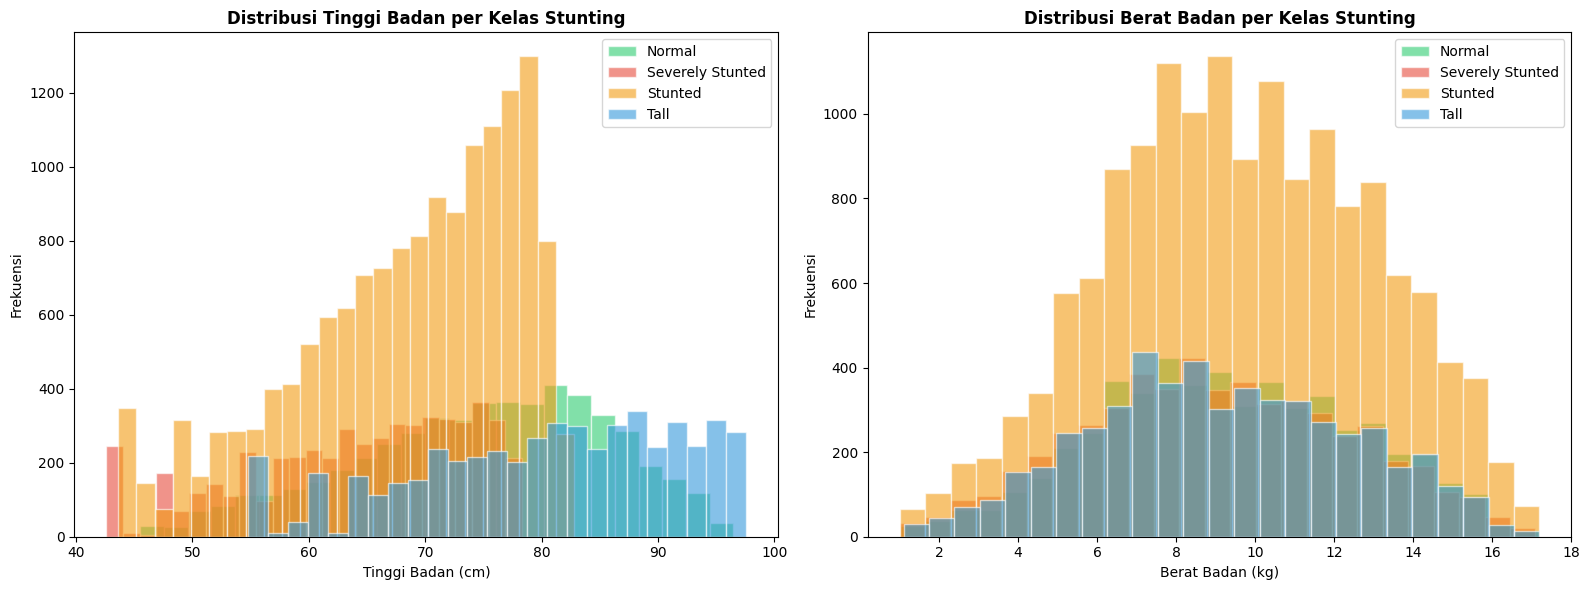

In [ ]:
# ============================================================
# 3.4 Distribusi Tinggi Badan per Kelas Stunting
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_kelas = {'Severely Stunted': '#e74c3c', 'Stunted': '#f39c12',
                'Normal': '#2ecc71', 'Tall': '#3498db'}

for kelas, grp in df.groupby('Stunting'):
    axes[0].hist(grp['Tinggi Badan (cm)'], bins=25, alpha=0.6,
                 label=kelas, color=colors_kelas.get(kelas,'gray'), edgecolor='white')
axes[0].set_title('Distribusi Tinggi Badan per Kelas Stunting', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tinggi Badan (cm)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

for kelas, grp in df.groupby('Stunting'):
    axes[1].hist(grp['Berat Badan (kg)'], bins=25, alpha=0.6,
                 label=kelas, color=colors_kelas.get(kelas,'gray'), edgecolor='white')
axes[1].set_title('Distribusi Berat Badan per Kelas Stunting', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Berat Badan (kg)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribusi_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

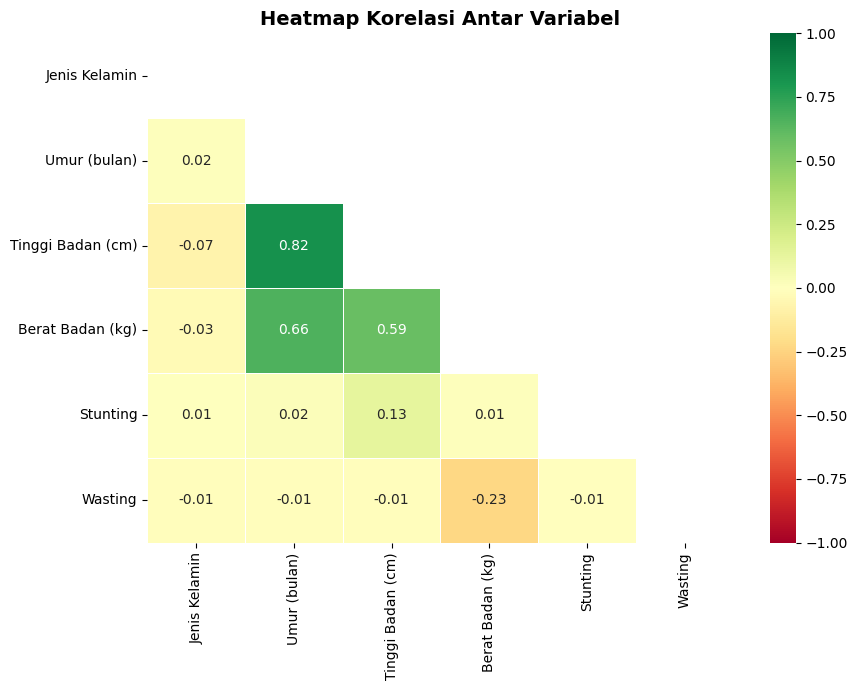

In [ ]:
# ============================================================
# 3.5 Heatmap Korelasi
# ============================================================
plt.figure(figsize=(9, 7))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1,
            annot_kws={'size': 10})
plt.title('Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

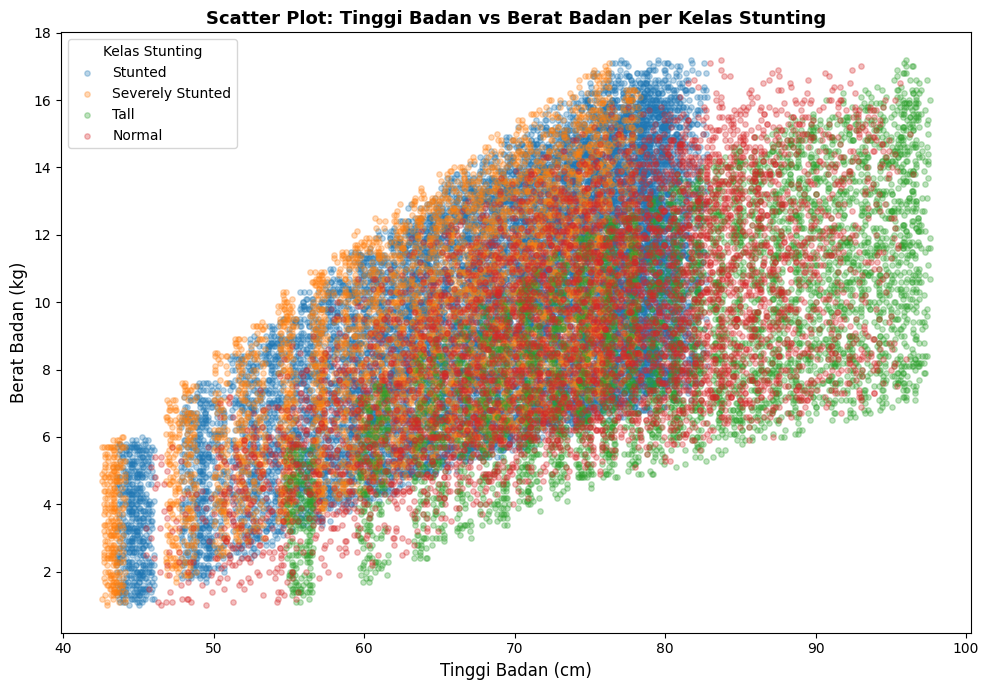

In [ ]:
# ============================================================
# 3.6 Scatter Plot: Tinggi vs Berat per Kelas Stunting
# ============================================================
plt.figure(figsize=(10, 7))
for kelas in df['Stunting'].unique():
    subset = df[df['Stunting'] == kelas]
    plt.scatter(subset['Tinggi Badan (cm)'], subset['Berat Badan (kg)'],
                alpha=0.3, label=kelas, s=15)
plt.xlabel('Tinggi Badan (cm)', fontsize=12)
plt.ylabel('Berat Badan (kg)', fontsize=12)
plt.title('Scatter Plot: Tinggi Badan vs Berat Badan per Kelas Stunting', fontsize=13, fontweight='bold')
plt.legend(title='Kelas Stunting')
plt.tight_layout()
plt.savefig('scatter_tinggi_berat.png', dpi=150, bbox_inches='tight')
plt.show()

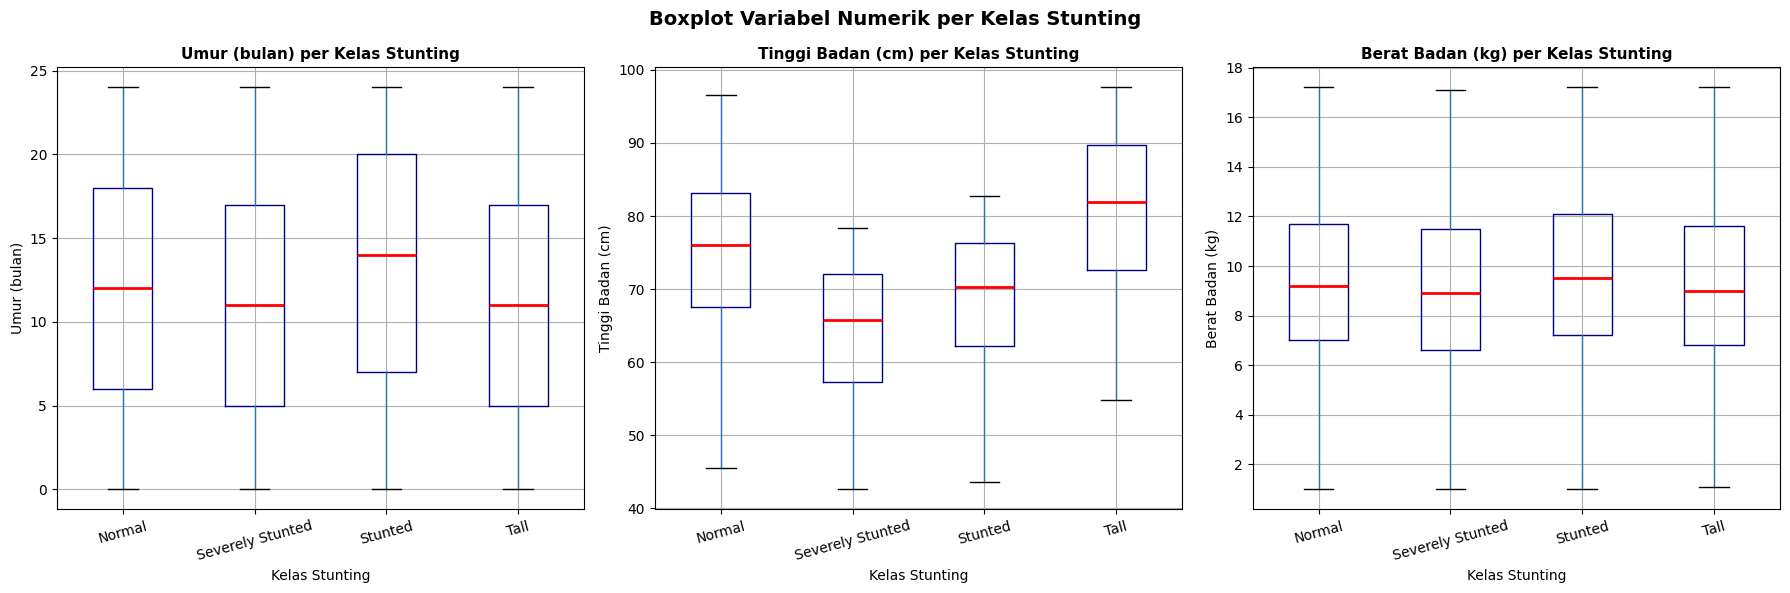

In [ ]:
# ============================================================
# 3.7 Boxplot per Kelas
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Stunting', ax=axes[i],
               boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} per Kelas Stunting', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Kelas Stunting')
    axes[i].set_ylabel(col)
    plt.sca(axes[i])
    plt.xticks(rotation=15)

plt.suptitle('Boxplot Variabel Numerik per Kelas Stunting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Normalisasi Data (StandardScaler)
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('✅ Normalisasi data selesai (StandardScaler)')
print(f'Rata-rata setelah scaling: {X_scaled.mean().round(4).to_dict()}')
print(f'Std setelah scaling: {X_scaled.std().round(4).to_dict()}')

✅ Normalisasi data selesai (StandardScaler)
Rata-rata setelah scaling: {'Jenis Kelamin': 0.0, 'Umur (bulan)': -0.0, 'Tinggi Badan (cm)': 0.0, 'Berat Badan (kg)': 0.0, 'Wasting': -0.0}
Std setelah scaling: {'Jenis Kelamin': 1.0, 'Umur (bulan)': 1.0, 'Tinggi Badan (cm)': 1.0, 'Berat Badan (kg)': 1.0, 'Wasting': 1.0}


In [ ]:
# ============================================================
# Definisi 3 Variasi Split
# ============================================================
splits = [
    {'label': '90:10', 'test_size': 0.10},
    {'label': '80:20', 'test_size': 0.20},
    {'label': '70:30', 'test_size': 0.30},
]

split_data = {}
for s in splits:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=s['test_size'], random_state=42, stratify=y
    )
    split_data[s['label']] = {
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_tr, 'y_test': y_te
    }
    print(f"Split {s['label']} → Train: {X_tr.shape[0]:,} | Test: {X_te.shape[0]:,}")

print('\n✅ Data splitting selesai!')

Split 90:10 → Train: 27,811 | Test: 3,091
Split 80:20 → Train: 24,721 | Test: 6,181
Split 70:30 → Train: 21,631 | Test: 9,271

✅ Data splitting selesai!


In [ ]:
# ============================================================
# Definisi Model Baseline
# ============================================================
models_baseline = {
    'SVM':           SVC(kernel='rbf', C=1, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5),
}

results_baseline = {}

for split_label, data in split_data.items():
    results_baseline[split_label] = {}
    X_tr = data['X_train']; X_te = data['X_test']
    y_tr = data['y_train']; y_te = data['y_test']

    for model_name, model in models_baseline.items():
        print(f'⏳ Training {model_name} | Split {split_label} ...')
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        acc  = accuracy_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred, average='weighted')
        prec = precision_score(y_te, y_pred, average='weighted')
        rec  = recall_score(y_te, y_pred, average='weighted')
        results_baseline[split_label][model_name] = {
            'model': model, 'y_pred': y_pred,
            'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec
        }
        print(f'   ✅ Accuracy={acc:.4f} | F1={f1:.4f} | Precision={prec:.4f} | Recall={rec:.4f}')

print('\n🏁 Semua model baseline selesai dilatih!')

⏳ Training SVM | Split 90:10 ...
   ✅ Accuracy=0.9243 | F1=0.9219 | Precision=0.9304 | Recall=0.9243
⏳ Training Random Forest | Split 90:10 ...
   ✅ Accuracy=0.9867 | F1=0.9866 | Precision=0.9870 | Recall=0.9867
⏳ Training KNN | Split 90:10 ...
   ✅ Accuracy=0.9188 | F1=0.9168 | Precision=0.9227 | Recall=0.9188
⏳ Training SVM | Split 80:20 ...
   ✅ Accuracy=0.9248 | F1=0.9224 | Precision=0.9306 | Recall=0.9248
⏳ Training Random Forest | Split 80:20 ...
   ✅ Accuracy=0.9882 | F1=0.9881 | Precision=0.9884 | Recall=0.9882
⏳ Training KNN | Split 80:20 ...
   ✅ Accuracy=0.9117 | F1=0.9097 | Precision=0.9156 | Recall=0.9117
⏳ Training SVM | Split 70:30 ...
   ✅ Accuracy=0.9219 | F1=0.9193 | Precision=0.9285 | Recall=0.9219
⏳ Training Random Forest | Split 70:30 ...
   ✅ Accuracy=0.9863 | F1=0.9862 | Precision=0.9866 | Recall=0.9863
⏳ Training KNN | Split 70:30 ...
   ✅ Accuracy=0.9057 | F1=0.9035 | Precision=0.9099 | Recall=0.9057

🏁 Semua model baseline selesai dilatih!


In [ ]:
# ============================================================
# 6.1 Definisi Grid Hyperparameter
# ============================================================

param_grids = {
    'SVM': {
        'C':      [0.1, 1, 10],
        'kernel': ['rbf', 'linear', 'poly'],
        'gamma':  ['scale', 'auto'],
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth':    [None, 10, 20],
        'min_samples_split': [2, 5],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 11],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan'],
    },
}

base_estimators = {
    'SVM':           SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN':           KNeighborsClassifier(),
}

print('✅ Grid hyperparameter didefinisikan!')
for m, p in param_grids.items():
    total_combs = 1
    for v in p.values(): total_combs *= len(v)
    print(f'  {m}: {total_combs} kombinasi')

✅ Grid hyperparameter didefinisikan!
  SVM: 18 kombinasi
  Random Forest: 18 kombinasi
  KNN: 16 kombinasi


In [ ]:
# ============================================================
# 6.2 GridSearchCV untuk setiap model dan setiap split
# (menggunakan subsample untuk efisiensi, bisa diubah ke full data)
# ============================================================

results_tuned = {}
best_params_all = {}

# Subsample untuk mempercepat GridSearch (gunakan semua data jika waktu cukup)
SUBSAMPLE = 5000  # Ubah ke None untuk full data

for split_label, data in split_data.items():
    results_tuned[split_label] = {}
    best_params_all[split_label] = {}
    X_tr = data['X_train']; X_te = data['X_test']
    y_tr = data['y_train']; y_te = data['y_test']

    # Subsample train set
    if SUBSAMPLE and len(X_tr) > SUBSAMPLE:
        idx = np.random.choice(len(X_tr), SUBSAMPLE, replace=False)
        X_tr_sub = X_tr.iloc[idx]; y_tr_sub = y_tr.iloc[idx]
    else:
        X_tr_sub = X_tr; y_tr_sub = y_tr

    for model_name, estimator in base_estimators.items():
        print(f'🔍 GridSearchCV: {model_name} | Split {split_label} ...')
        gs = GridSearchCV(
            estimator=estimator,
            param_grid=param_grids[model_name],
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        gs.fit(X_tr_sub, y_tr_sub)

        best_model = gs.best_estimator_
        # Re-train best model on FULL train set
        best_model.fit(X_tr, y_tr)
        y_pred = best_model.predict(X_te)

        acc  = accuracy_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred, average='weighted')
        prec = precision_score(y_te, y_pred, average='weighted')
        rec  = recall_score(y_te, y_pred, average='weighted')

        results_tuned[split_label][model_name] = {
            'model': best_model, 'y_pred': y_pred,
            'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec,
            'best_params': gs.best_params_,
            'cv_best_score': gs.best_score_
        }
        best_params_all[split_label][model_name] = gs.best_params_

        print(f'   Best Params : {gs.best_params_}')
        print(f'   CV Score    : {gs.best_score_:.4f}')
        print(f'   Test Acc    : {acc:.4f} | F1={f1:.4f}')
        print()

print('🏁 Hyperparameter tuning selesai!')

🔍 GridSearchCV: SVM | Split 90:10 ...
   Best Params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   CV Score    : 0.9304
   Test Acc    : 0.9735 | F1=0.9731

🔍 GridSearchCV: Random Forest | Split 90:10 ...
   Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
   CV Score    : 0.9106
   Test Acc    : 0.9867 | F1=0.9866

🔍 GridSearchCV: KNN | Split 90:10 ...
   Best Params : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
   CV Score    : 0.8162
   Test Acc    : 0.9340 | F1=0.9332

🔍 GridSearchCV: SVM | Split 80:20 ...
   Best Params : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
   CV Score    : 0.9272
   Test Acc    : 0.9710 | F1=0.9708

🔍 GridSearchCV: Random Forest | Split 80:20 ...
   Best Params : {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
   CV Score    : 0.9048
   Test Acc    : 0.9856 | F1=0.9855

🔍 GridSearchCV: KNN | Split 80:20 ...
   Best Params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'

📋 EVALUASI MODEL — Split 90:10

--- SVM (Setelah Tuning) ---
                  precision    recall  f1-score   support

          Normal       1.00      0.89      0.94       527
Severely Stunted       0.98      0.98      0.98       533
         Stunted       0.98      0.99      0.98      1504
            Tall       0.94      1.00      0.97       527

        accuracy                           0.97      3091
       macro avg       0.97      0.97      0.97      3091
    weighted avg       0.97      0.97      0.97      3091


--- Random Forest (Setelah Tuning) ---
                  precision    recall  f1-score   support

          Normal       1.00      0.93      0.96       527
Severely Stunted       1.00      1.00      1.00       533
         Stunted       0.99      1.00      0.99      1504
            Tall       0.97      1.00      0.98       527

        accuracy                           0.99      3091
       macro avg       0.99      0.98      0.98      3091
    weighted avg       0

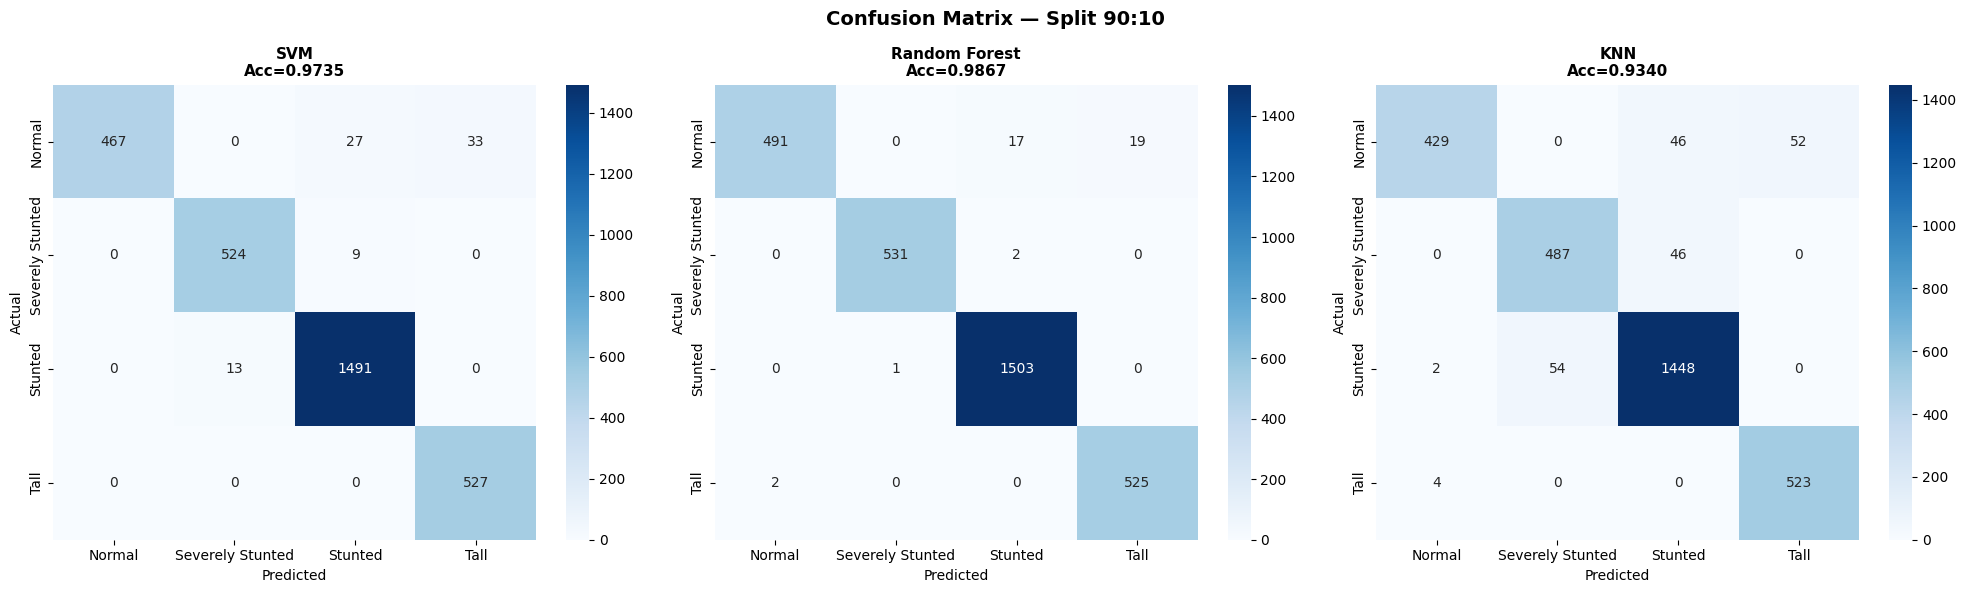

📋 EVALUASI MODEL — Split 80:20

--- SVM (Setelah Tuning) ---
                  precision    recall  f1-score   support

          Normal       1.00      0.90      0.95      1053
Severely Stunted       0.97      0.97      0.97      1067
         Stunted       0.97      0.99      0.98      3008
            Tall       0.95      1.00      0.97      1053

        accuracy                           0.97      6181
       macro avg       0.97      0.96      0.97      6181
    weighted avg       0.97      0.97      0.97      6181


--- Random Forest (Setelah Tuning) ---
                  precision    recall  f1-score   support

          Normal       1.00      0.93      0.96      1053
Severely Stunted       1.00      0.99      0.99      1067
         Stunted       0.98      1.00      0.99      3008
            Tall       0.97      1.00      0.98      1053

        accuracy                           0.99      6181
       macro avg       0.99      0.98      0.98      6181
    weighted avg       0

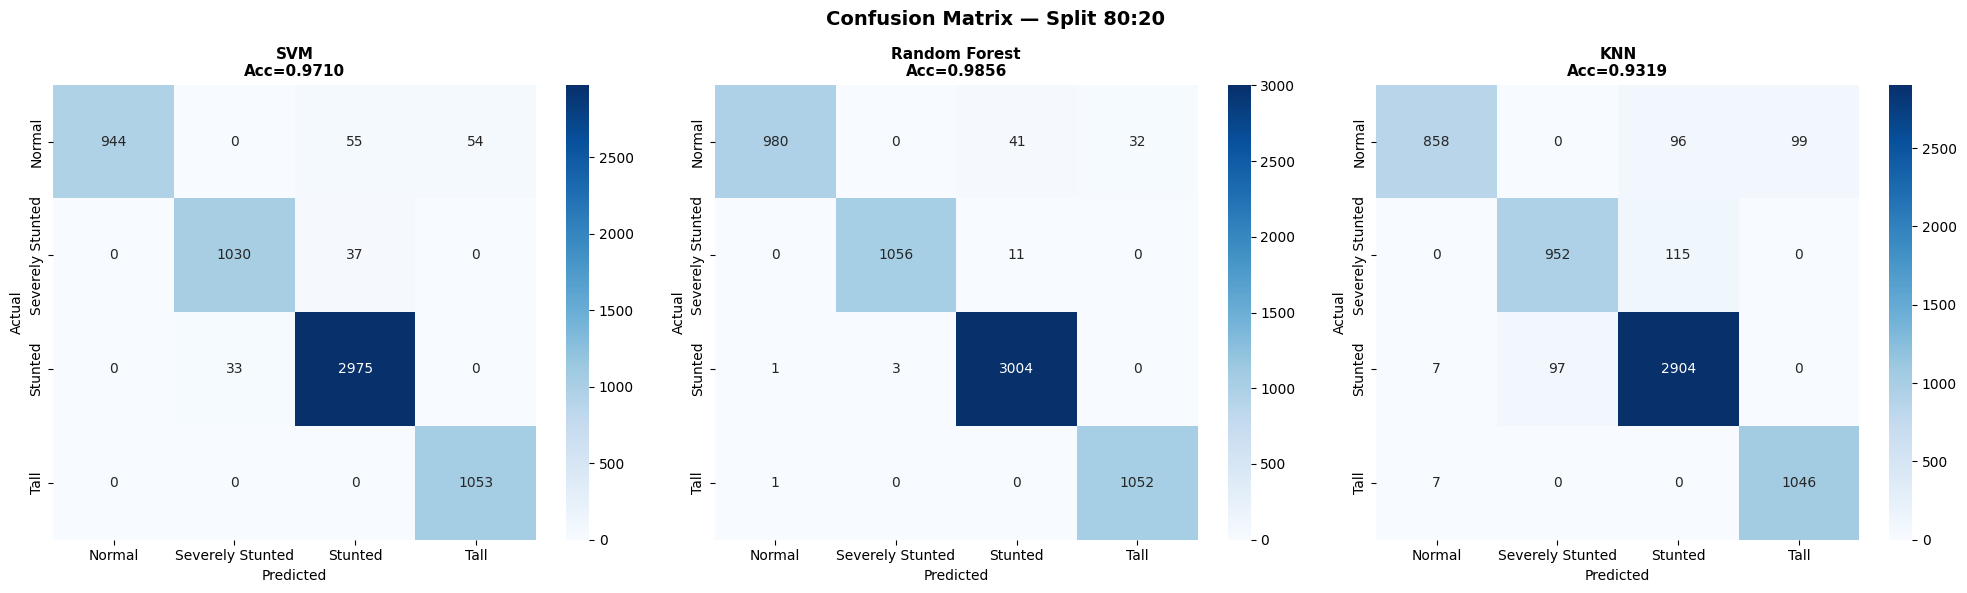

📋 EVALUASI MODEL — Split 70:30

--- SVM (Setelah Tuning) ---
                  precision    recall  f1-score   support

          Normal       1.00      0.89      0.94      1580
Severely Stunted       0.98      0.96      0.97      1600
         Stunted       0.97      0.99      0.98      4512
            Tall       0.95      1.00      0.97      1579

        accuracy                           0.97      9271
       macro avg       0.97      0.96      0.97      9271
    weighted avg       0.97      0.97      0.97      9271


--- Random Forest (Setelah Tuning) ---
                  precision    recall  f1-score   support

          Normal       1.00      0.93      0.97      1580
Severely Stunted       0.99      0.99      0.99      1600
         Stunted       0.98      1.00      0.99      4512
            Tall       0.97      1.00      0.99      1579

        accuracy                           0.99      9271
       macro avg       0.99      0.98      0.98      9271
    weighted avg       0

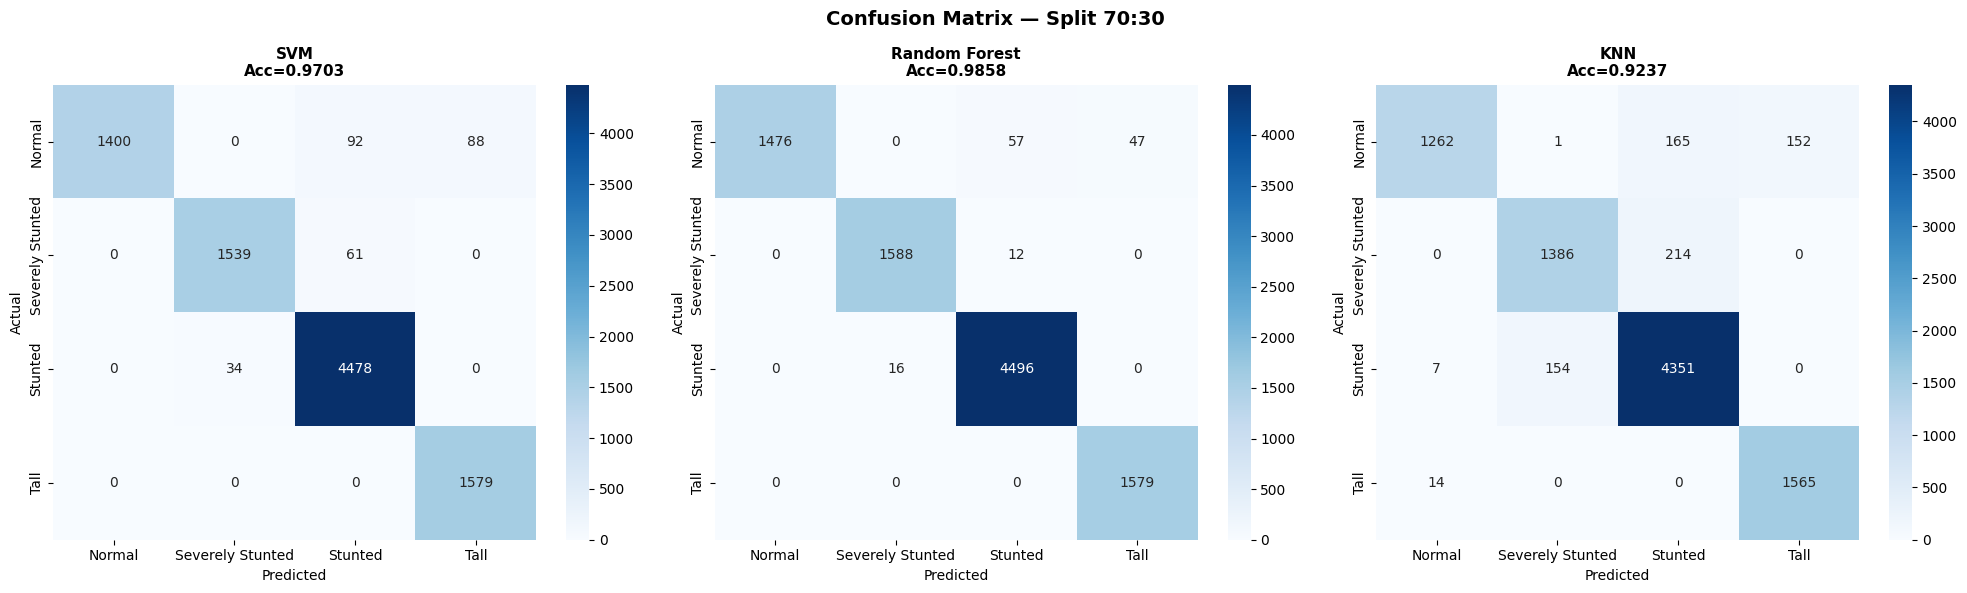

In [ ]:
# ============================================================
# 7.1 Classification Report & Confusion Matrix (Model Tuned)
# ============================================================
label_names = le_dict['Stunting'].classes_

for split_label, data in split_data.items():
    y_te = data['y_test']
    print('=' * 70)
    print(f'📋 EVALUASI MODEL — Split {split_label}')
    print('=' * 70)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for idx, model_name in enumerate(['SVM', 'Random Forest', 'KNN']):
        r = results_tuned[split_label][model_name]
        print(f'\n--- {model_name} (Setelah Tuning) ---')
        print(classification_report(y_te, r['y_pred'], target_names=label_names))

        cm = confusion_matrix(y_te, r['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=label_names, yticklabels=label_names)
        axes[idx].set_title(f'{model_name}\nAcc={r["accuracy"]:.4f}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    plt.suptitle(f'Confusion Matrix — Split {split_label}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{split_label.replace(":","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ============================================================
# 8.1 Tabel Perbandingan Lengkap
# ============================================================

rows_baseline = []
rows_tuned    = []

for split_label in ['90:10','80:20','70:30']:
    for model_name in ['SVM','Random Forest','KNN']:
        rb = results_baseline[split_label][model_name]
        rows_baseline.append({
            'Split': split_label, 'Model': model_name,
            'Accuracy': round(rb['accuracy'],4),
            'Precision': round(rb['precision'],4),
            'Recall': round(rb['recall'],4),
            'F1-Score': round(rb['f1'],4),
        })
        rt = results_tuned[split_label][model_name]
        rows_tuned.append({
            'Split': split_label, 'Model': model_name,
            'Accuracy': round(rt['accuracy'],4),
            'Precision': round(rt['precision'],4),
            'Recall': round(rt['recall'],4),
            'F1-Score': round(rt['f1'],4),
            'Best Params': str(rt['best_params']),
            'CV Score': round(rt['cv_best_score'],4),
        })

df_baseline = pd.DataFrame(rows_baseline)
df_tuned    = pd.DataFrame(rows_tuned)

print('=' * 80)
print('📊 TABEL PERBANDINGAN MODEL — BASELINE (Sebelum Tuning)')
print('=' * 80)
print(df_baseline.to_string(index=False))

print('\n')
print('=' * 80)
print('📊 TABEL PERBANDINGAN MODEL — AFTER TUNING (Setelah Hyperparameter Tuning)')
print('=' * 80)
print(df_tuned.to_string(index=False))

📊 TABEL PERBANDINGAN MODEL — BASELINE (Sebelum Tuning)
Split         Model  Accuracy  Precision  Recall  F1-Score
90:10           SVM    0.9243     0.9304  0.9243    0.9219
90:10 Random Forest    0.9867     0.9870  0.9867    0.9866
90:10           KNN    0.9188     0.9227  0.9188    0.9168
80:20           SVM    0.9248     0.9306  0.9248    0.9224
80:20 Random Forest    0.9882     0.9884  0.9882    0.9881
80:20           KNN    0.9117     0.9156  0.9117    0.9097
70:30           SVM    0.9219     0.9285  0.9219    0.9193
70:30 Random Forest    0.9863     0.9866  0.9863    0.9862
70:30           KNN    0.9057     0.9099  0.9057    0.9035


📊 TABEL PERBANDINGAN MODEL — AFTER TUNING (Setelah Hyperparameter Tuning)
Split         Model  Accuracy  Precision  Recall  F1-Score                                                      Best Params  CV Score
90:10           SVM    0.9735     0.9743  0.9735    0.9731                     {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}    0.9304
90:10 Rando

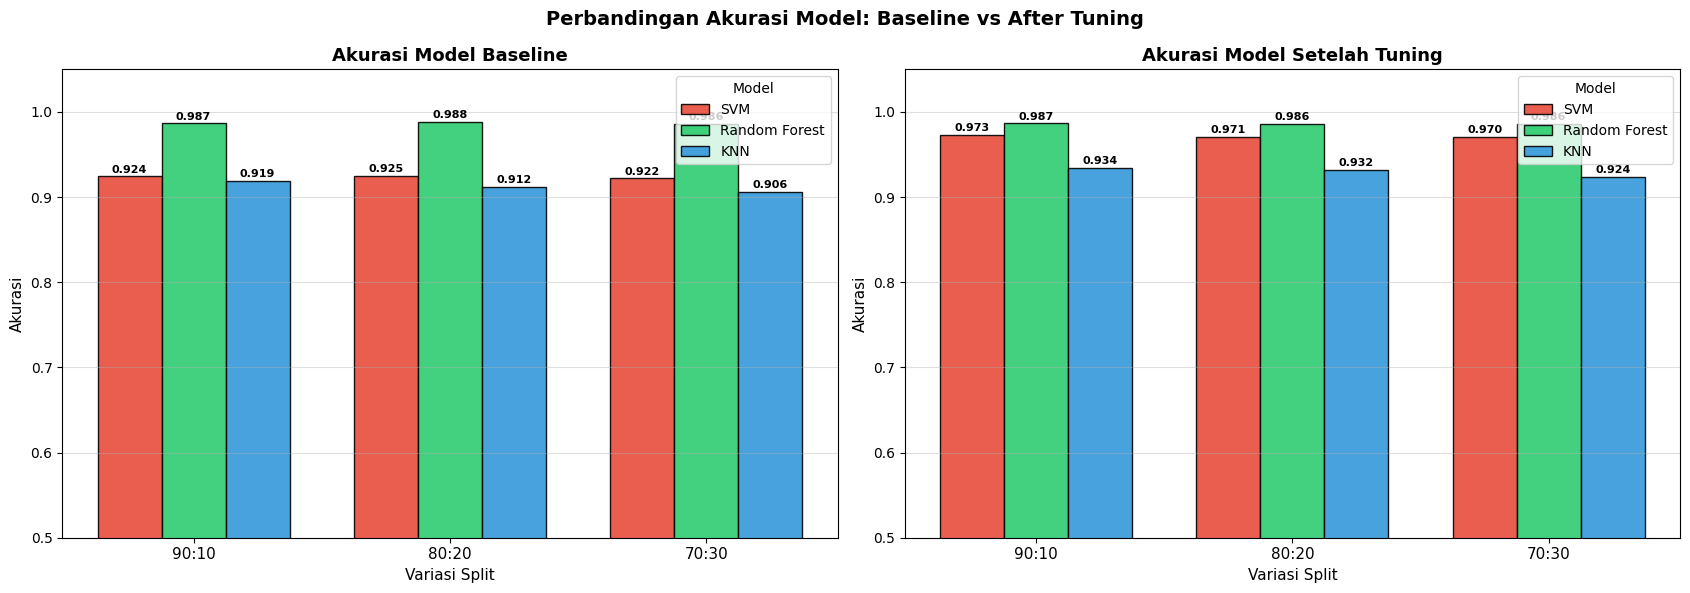

In [ ]:
# ============================================================
# 8.2 Visualisasi Perbandingan Akurasi — Baseline
# ============================================================
splits_list  = ['90:10','80:20','70:30']
models_list  = ['SVM','Random Forest','KNN']
colors_model = {'SVM':'#e74c3c','Random Forest':'#2ecc71','KNN':'#3498db'}
x = np.arange(len(splits_list))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, results, title in [
    (axes[0], results_baseline, 'Akurasi Model Baseline'),
    (axes[1], results_tuned,    'Akurasi Model Setelah Tuning')
]:
    for i, model_name in enumerate(models_list):
        accs = [results[sl][model_name]['accuracy'] for sl in splits_list]
        bars = ax.bar(x + i*width, accs, width, label=model_name,
                      color=colors_model[model_name], edgecolor='black', alpha=0.9)
        for bar, v in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Variasi Split', fontsize=11)
    ax.set_ylabel('Akurasi', fontsize=11)
    ax.set_xticks(x + width)
    ax.set_xticklabels(splits_list, fontsize=11)
    ax.set_ylim(0.5, 1.05)
    ax.legend(title='Model', fontsize=10)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Perbandingan Akurasi Model: Baseline vs After Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('perbandingan_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()

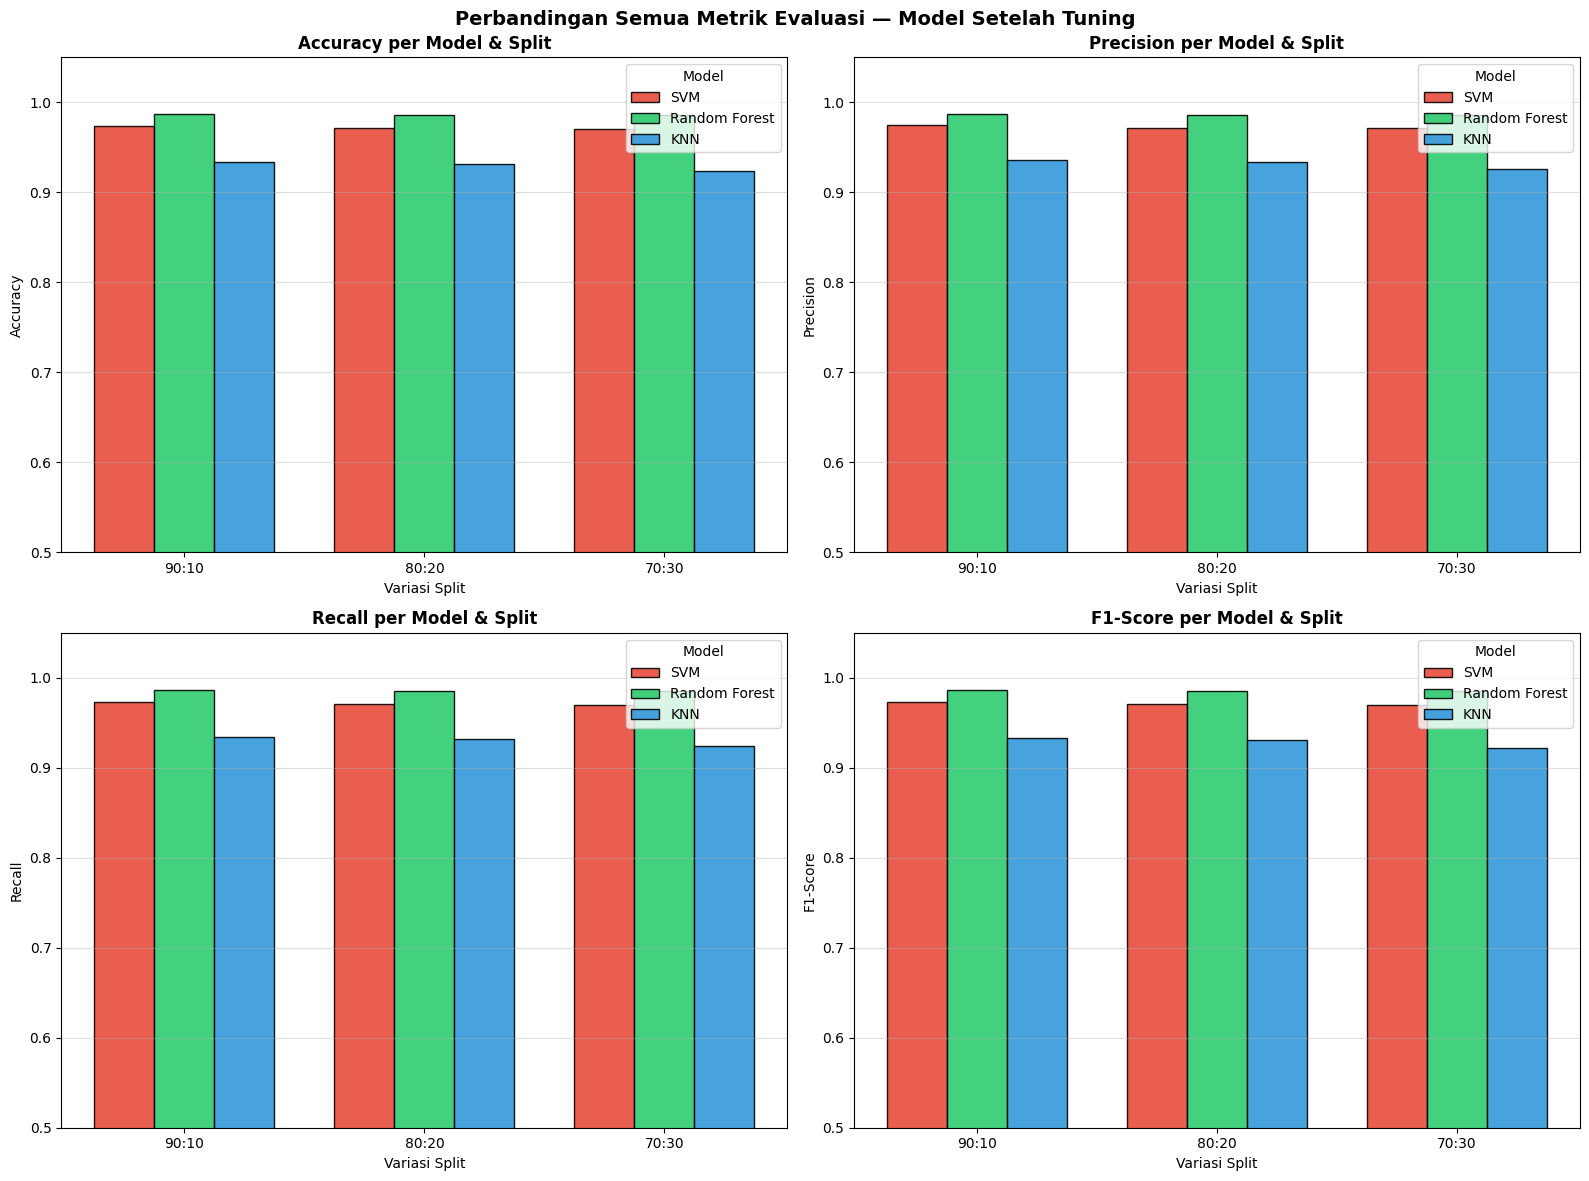

In [ ]:
# ============================================================
# 8.3 Visualisasi Semua Metrik (F1, Precision, Recall, Accuracy)
# ============================================================
metrics = ['accuracy','precision','recall','f1']
metric_labels = ['Accuracy','Precision','Recall','F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for m_idx, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):
    ax = axes[m_idx]
    for i, model_name in enumerate(models_list):
        vals = [results_tuned[sl][model_name][metric] for sl in splits_list]
        ax.bar(x + i*width, vals, width, label=model_name,
               color=colors_model[model_name], edgecolor='black', alpha=0.9)
    ax.set_title(f'{mlabel} per Model & Split', fontsize=12, fontweight='bold')
    ax.set_xlabel('Variasi Split')
    ax.set_ylabel(mlabel)
    ax.set_xticks(x + width)
    ax.set_xticklabels(splits_list)
    ax.set_ylim(0.5, 1.05)
    ax.legend(title='Model')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Perbandingan Semua Metrik Evaluasi — Model Setelah Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('semua_metrik.png', dpi=150, bbox_inches='tight')
plt.show()

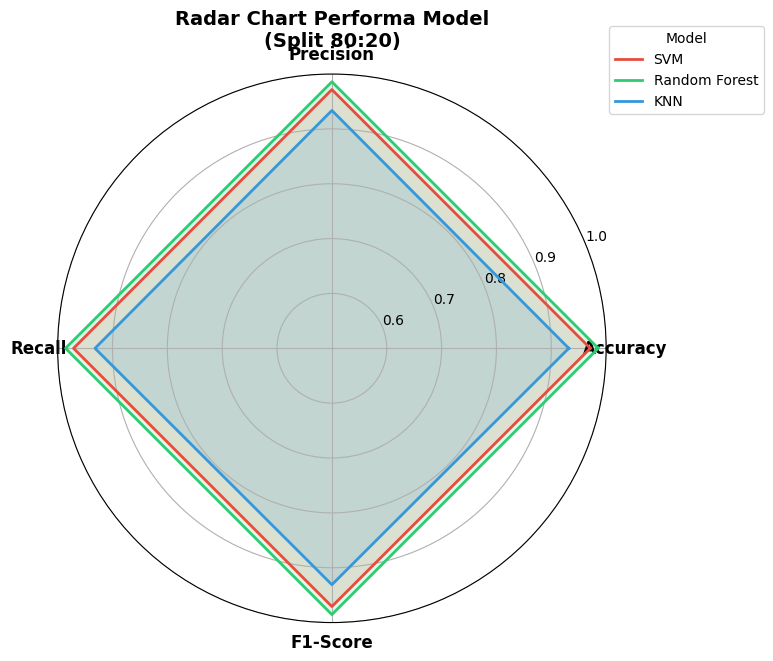

In [ ]:
# ============================================================
# 8.4 Radar Chart Perbandingan Model (Split Terbaik)
# ============================================================
# Gunakan split 80:20 sebagai representasi terbaik
best_split = '80:20'

categories = ['Accuracy','Precision','Recall','F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_r = ['#e74c3c','#2ecc71','#3498db']

for idx, model_name in enumerate(models_list):
    r = results_tuned[best_split][model_name]
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1']]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, linestyle='solid', label=model_name, color=colors_r[idx])
    ax.fill(angles, vals, alpha=0.15, color=colors_r[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.set_title(f'Radar Chart Performa Model\n(Split {best_split})', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Model')

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 8.5 Ringkasan Final + Model Terbaik
# ============================================================
print('=' * 80)
print('🏆 RINGKASAN PERFORMA MODEL SETELAH HYPERPARAMETER TUNING')
print('=' * 80)
print(f'{"Split":<10} {"Model":<18} {"Accuracy":<12} {"Precision":<12} {"Recall":<12} {"F1-Score":<12}')
print('-' * 76)

best_acc = 0
best_info = {}

for split_label in splits_list:
    for model_name in models_list:
        r = results_tuned[split_label][model_name]
        marker = ' ⭐' if r['accuracy'] > best_acc else ''
        if r['accuracy'] > best_acc:
            best_acc = r['accuracy']
            best_info = {'split': split_label, 'model': model_name, **r}
        print(f"{split_label:<10} {model_name:<18} {r['accuracy']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f} {r['f1']:<12.4f}{marker}")

print('=' * 80)
print(f'\n🥇 MODEL TERBAIK  : {best_info["model"]}')
print(f'📌 Variasi Split  : {best_info["split"]}')
print(f'🎯 Akurasi        : {best_info["accuracy"]:.4f} ({best_info["accuracy"]*100:.2f}%)')
print(f'📊 F1-Score       : {best_info["f1"]:.4f}')
print(f'⚙️  Best Params    : {best_info["best_params"]}')

🏆 RINGKASAN PERFORMA MODEL SETELAH HYPERPARAMETER TUNING
Split      Model              Accuracy     Precision    Recall       F1-Score    
----------------------------------------------------------------------------
90:10      SVM                0.9735       0.9743       0.9735       0.9731       ⭐
90:10      Random Forest      0.9867       0.9870       0.9867       0.9866       ⭐
90:10      KNN                0.9340       0.9359       0.9340       0.9332      
80:20      SVM                0.9710       0.9717       0.9710       0.9708      
80:20      Random Forest      0.9856       0.9859       0.9856       0.9855      
80:20      KNN                0.9319       0.9336       0.9319       0.9310      
70:30      SVM                0.9703       0.9712       0.9703       0.9700      
70:30      Random Forest      0.9858       0.9860       0.9858       0.9856      
70:30      KNN                0.9237       0.9258       0.9237       0.9225      

🥇 MODEL TERBAIK  : RandomForestClassifier

In [ ]:
# ============================================================
# 8.6 Perbandingan Peningkatan Akurasi (Baseline vs Tuned)
# ============================================================
print('\n📈 PENINGKATAN AKURASI: BASELINE vs AFTER TUNING')
print('=' * 65)
print(f'{"Split":<10} {"Model":<18} {"Baseline":<12} {"Tuned":<12} {"Delta":<10}')
print('-' * 65)

for split_label in splits_list:
    for model_name in models_list:
        base_acc  = results_baseline[split_label][model_name]['accuracy']
        tuned_acc = results_tuned[split_label][model_name]['accuracy']
        delta = tuned_acc - base_acc
        sign  = '+' if delta >= 0 else ''
        print(f"{split_label:<10} {model_name:<18} {base_acc:<12.4f} {tuned_acc:<12.4f} {sign}{delta:.4f}")


📈 PENINGKATAN AKURASI: BASELINE vs AFTER TUNING
Split      Model              Baseline     Tuned        Delta     
-----------------------------------------------------------------
90:10      SVM                0.9243       0.9735       +0.0492
90:10      Random Forest      0.9867       0.9867       +0.0000
90:10      KNN                0.9188       0.9340       +0.0152
80:20      SVM                0.9248       0.9710       +0.0463
80:20      Random Forest      0.9882       0.9856       -0.0026
80:20      KNN                0.9117       0.9319       +0.0202
70:30      SVM                0.9219       0.9703       +0.0484
70:30      Random Forest      0.9863       0.9858       -0.0005
70:30      KNN                0.9057       0.9237       +0.0180


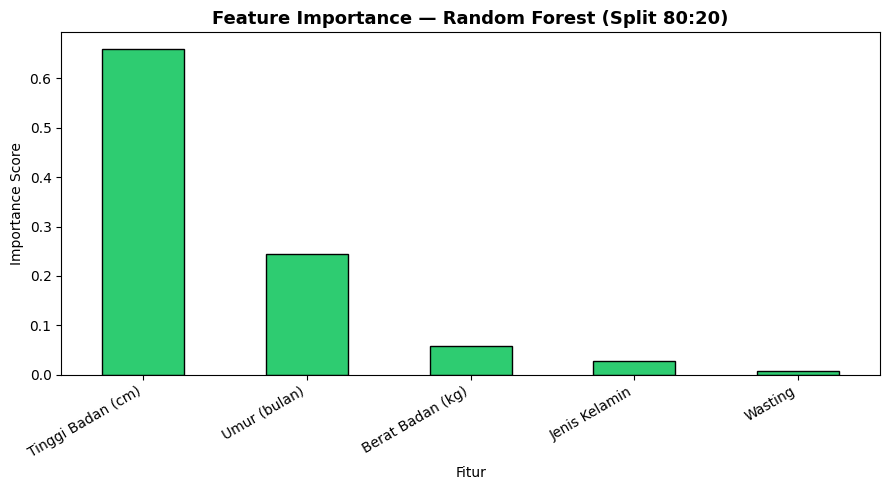


📌 Feature Importance (Random Forest):
Tinggi Badan (cm)    0.660251
Umur (bulan)         0.244101
Berat Badan (kg)     0.058387
Jenis Kelamin        0.028778
Wasting              0.008483


In [ ]:
# ============================================================
# 8.7 Feature Importance (Random Forest)
# ============================================================
best_rf = results_tuned['80:20']['Random Forest']['model']
feat_importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_importance.plot(kind='bar', color='#2ecc71', edgecolor='black')
plt.title('Feature Importance — Random Forest (Split 80:20)', fontsize=13, fontweight='bold')
plt.xlabel('Fitur')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Feature Importance (Random Forest):')
print(feat_importance.to_string())